In [8]:
import pandas as pd
import os
import json
import pickle
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# load ss-shock

In [3]:
DIR = "/lfs/local/0/serinac/supply-chains/TGB/tgb/datasets/tgbl_hypergraph_synthetic_shocks"
edgelist = "tgbl-hypergraph_synthetic_shocks_edgelist.csv"
metajson = "tgbl-hypergraph_synthetic_shocks_meta.json"

shock_data = pd.read_csv(os.path.join(DIR, edgelist))
print(shock_data.shape)
shock_data.head()

# TODO; change back, just a hack for now
shock_data['weight'] = 1
shock_data

(56381, 5)


,ts,source,target,product,weight
0,2,23,6,119,1
1,2,5,17,122,1
2,2,4,43,121,1
3,2,23,19,122,1
4,2,19,43,122,1
...,...,...,...,...,...
56376,199,65,73,143,1
56377,199,23,52,130,1
56378,199,59,78,149,1
56379,199,64,74,143,1


In [4]:
with open("/lfs/local/0/zhiyinl/supply-chains/synthetic_data/synthetic_data.pkl", 'rb') as f:
    prod_info = pickle.load(f)
    
num_firms = len(prod_info[0])
num_prods = len(prod_info[1])
prod_graph = prod_info[2]
prod_graph

,source,dest,units,layer
0,product1,product5,3,1
1,product4,product5,4,1
2,product0,product5,3,1
3,product3,product6,4,1
4,product0,product6,2,1
...,...,...,...,...
128,product37,product48,3,5
129,product42,product48,4,5
130,product37,product49,4,5
131,product43,product49,4,5


In [20]:
prod_info[2]

,source,dest,units,layer
0,product1,product5,3,1
1,product4,product5,4,1
2,product0,product5,3,1
3,product3,product6,4,1
4,product0,product6,2,1
...,...,...,...,...
128,product37,product48,3,5
129,product42,product48,4,5
130,product37,product49,4,5
131,product43,product49,4,5


# generate ground-truth labels
tracking how shocks trickle down

shocks happen to 
* product 0 at times 32 and 144
* product 2 at times 42 and 155
* product 3 at times 51, 90, and 144
* product 4 at times 16, 58, and 131

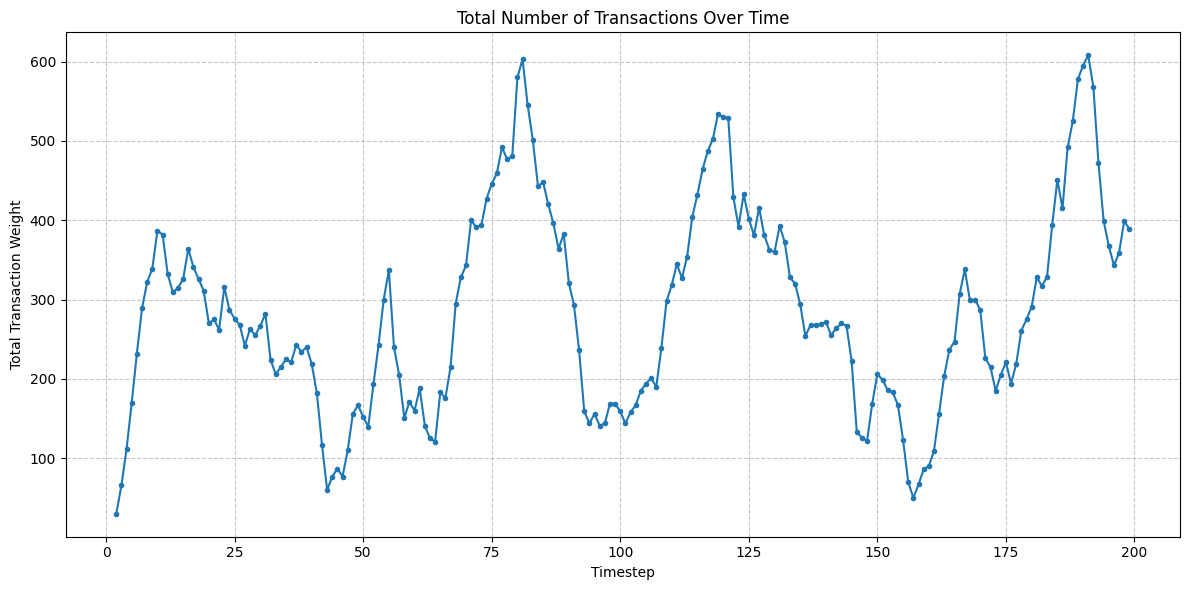

In [5]:
# Plot the total number of transactions over timesteps

# Group by timestep and sum the weights
transactions_per_timestep = shock_data.groupby('ts')['weight'].sum().reset_index()

# Sort by timestep to ensure chronological order
transactions_per_timestep = transactions_per_timestep.sort_values('ts')

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(transactions_per_timestep['ts'], transactions_per_timestep['weight'], marker='.')

# Customize the plot
plt.title('Total Number of Transactions Over Time')
plt.xlabel('Timestep')
plt.ylabel('Total Transaction Weight')
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

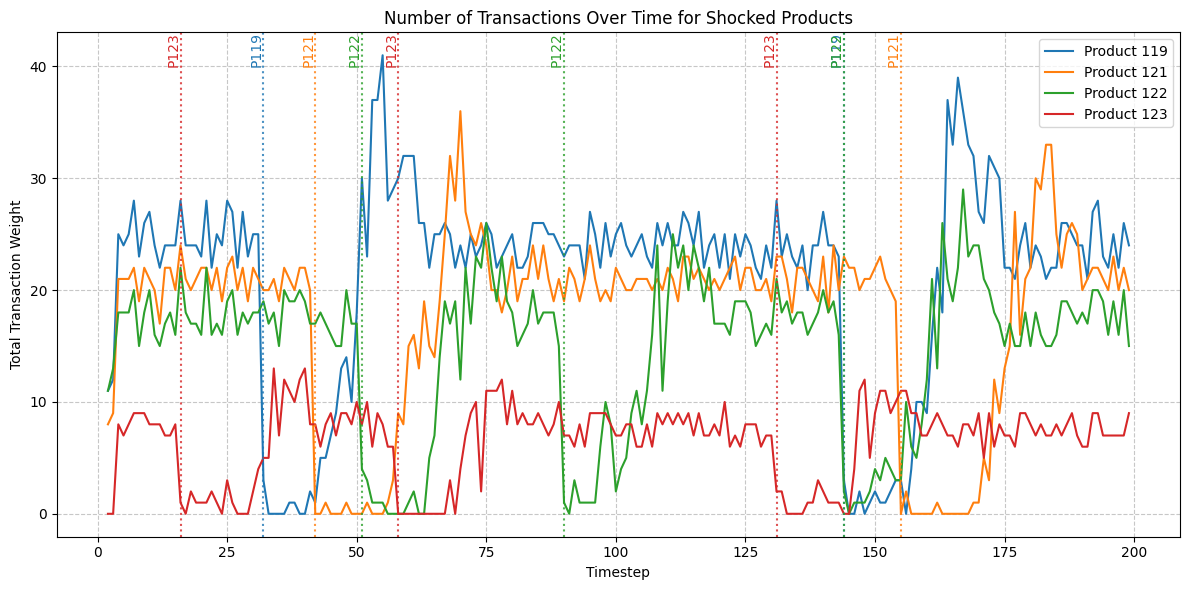

In [6]:
# Plot shocks on exogenous supply

# (given) shock times
shock_times = {
    119: [32, 144],
    121: [42, 155],
    122: [51, 90, 144],
    123: [16, 58, 131]
}

# List of products that experience shocks
shocked_products = shock_times.keys()

# Group by timestep and product, then sum the weights
transactions_per_product = shock_data.groupby(['ts', 'product'])['weight'].sum().unstack(fill_value=0)

# Filter for only the shocked products
shocked_transactions = transactions_per_product[shocked_products]

# Create the plot
plt.figure(figsize=(12, 6))

# Define a color map for the products
colors = plt.cm.tab10.colors
color_map = {
    119: colors[0], 
    121: colors[1], 
    122: colors[2],
    123: colors[3]
}

# Plot each shocked product
for product in shocked_products:
    plt.plot(shocked_transactions.index, shocked_transactions[product], 
             label=f'Product {product}', color=color_map[product])

# Customize the plot
plt.title('Number of Transactions Over Time for Shocked Products')
plt.xlabel('Timestep')
plt.ylabel('Total Transaction Weight')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

for product, times in shock_times.items():
    for time in times:
        plt.axvline(x=time, color=color_map[product], linestyle=':', alpha=0.8)
        plt.text(time, plt.ylim()[1], f'P{product}', rotation=90, va='top', ha='right', 
                 color=color_map[product])

# Show the plot
plt.tight_layout()
plt.show()

p0 -> p1 -> p2 -> p3 -> p4: p0 dorps, tehrefore everyone drops
      p1prime -> p2
        
      p1prime -> p2primeprime

because p1 drops therefore p2 drops, we have increased ample p1prime
 -> p2primeprime go up
    
This will happen if initially # demand > # of supply

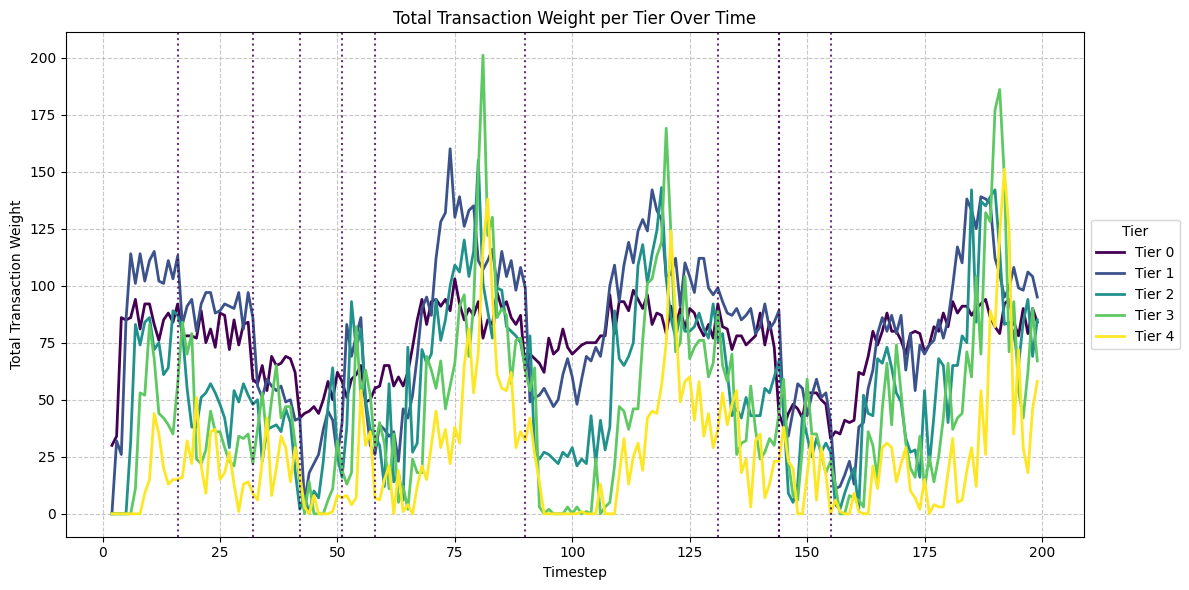

In [10]:
# Plot number of transactions per tier

def get_product_tiers(products):
    """
    Assign tiers to products based on their index.
    First 5 products are tier 0, next 10 is tier 1, next 10 is tier 2, 
    next 10 is tier 3, and last 5 is tier 4.
    """
    tiers = {}
    products = set(prod_graph['source'].unique()) | set(prod_graph['dest'].unique())
    for product in products:
        i = int(product.replace('product', ''))
        if i < 5:
            tiers[product] = 0
        elif i < 15:
            tiers[product] = 1
        elif i < 25:
            tiers[product] = 2
        elif i < 35:
            tiers[product] = 3
        else:
            tiers[product] = 4
    return tiers

# Get product tiers
product_tiers = get_product_tiers(prod_graph)

# Create a mapping from product ID to tier
PROD_OFFSET = 119
product_id_to_tier = {int(prod_name.replace('product', '')) + PROD_OFFSET: tier 
                      for prod_name, tier in product_tiers.items()}

# Add tier information to the shock_data
shock_data['tier'] = shock_data['product'].map(product_id_to_tier)

# Group by time and tier, count the number of transactions
transactions_per_tier = shock_data.groupby(['ts', 'tier'])['weight'].sum().unstack(fill_value=0)

# Create the stacked area plot
fig, ax = plt.subplots(figsize=(12, 6))

# Get the viridis colormap
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(transactions_per_tier.columns)))

# Plot each tier as a separate line
for i, tier in enumerate(transactions_per_tier.columns):
    ax.plot(transactions_per_tier.index, transactions_per_tier[tier], 
            color=colors[i], label=f'Tier {tier}', linewidth=2)

# Customize the plot
ax.set_title('Total Transaction Weight per Tier Over Time')
ax.set_xlabel('Timestep')
ax.set_ylabel('Total Transaction Weight')
ax.legend(title='Tier', loc='center left', bbox_to_anchor=(1, 0.5))

# Add grid for better readability
ax.grid(True, linestyle='--', alpha=0.7)

# Plot shocks
for product, times in shock_times.items():
    for time in times:
        plt.axvline(x=time, color=colors[0], linestyle=':', alpha=0.8)

        
# Adjust layout and show plot
plt.tight_layout()
plt.show()

scaling factors by tiers are: {0: 1, 1: 4, 2: 16, 3: 64, 4: 256}


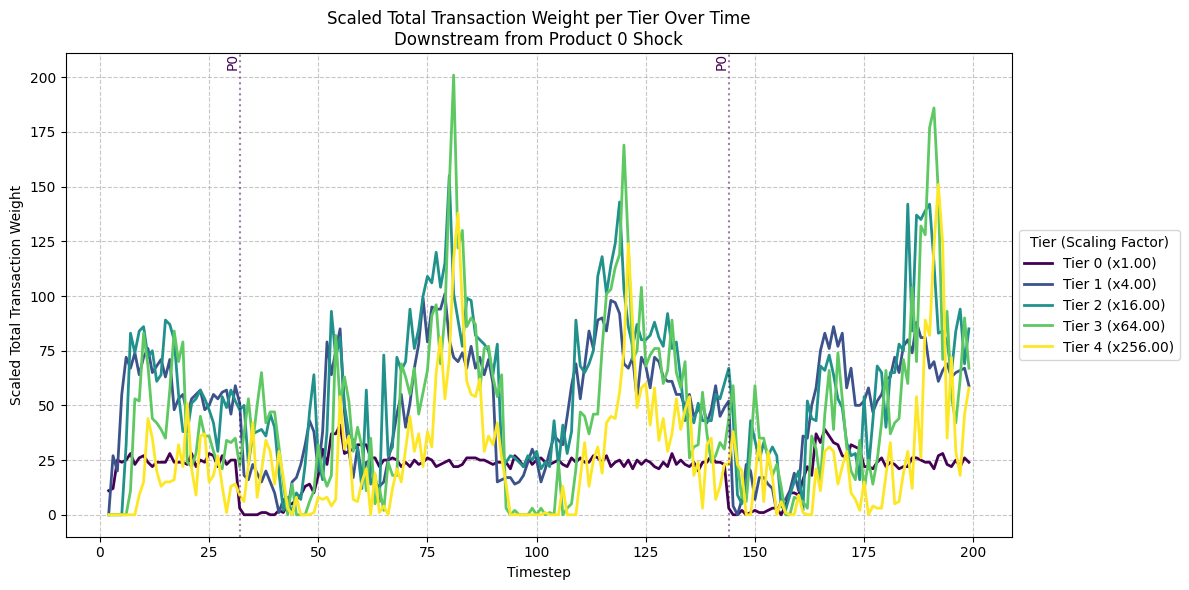

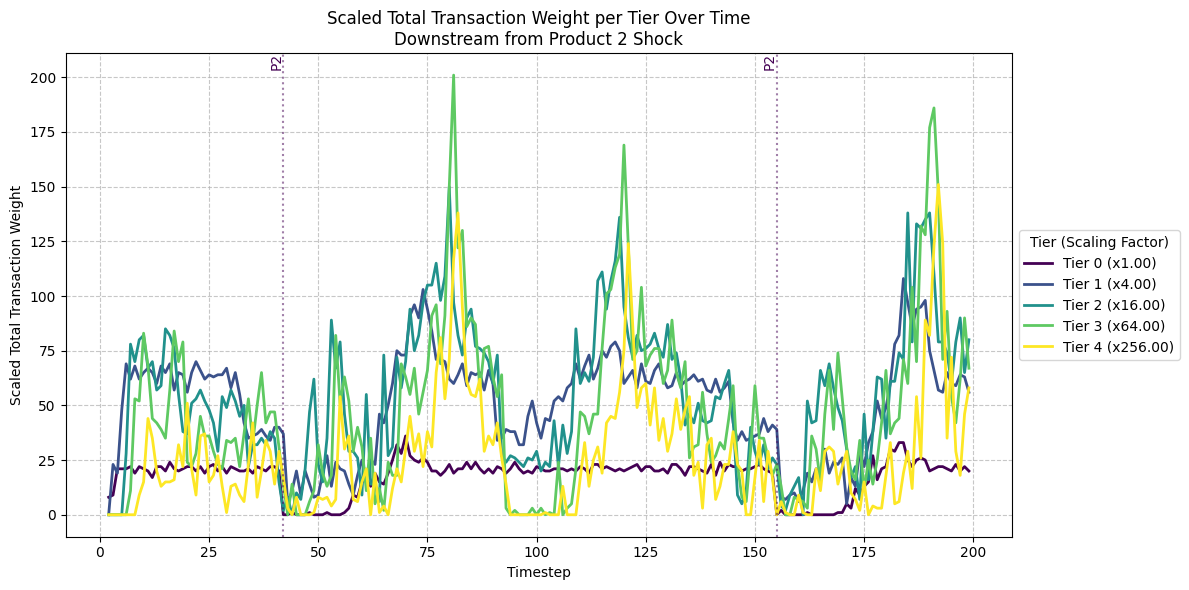

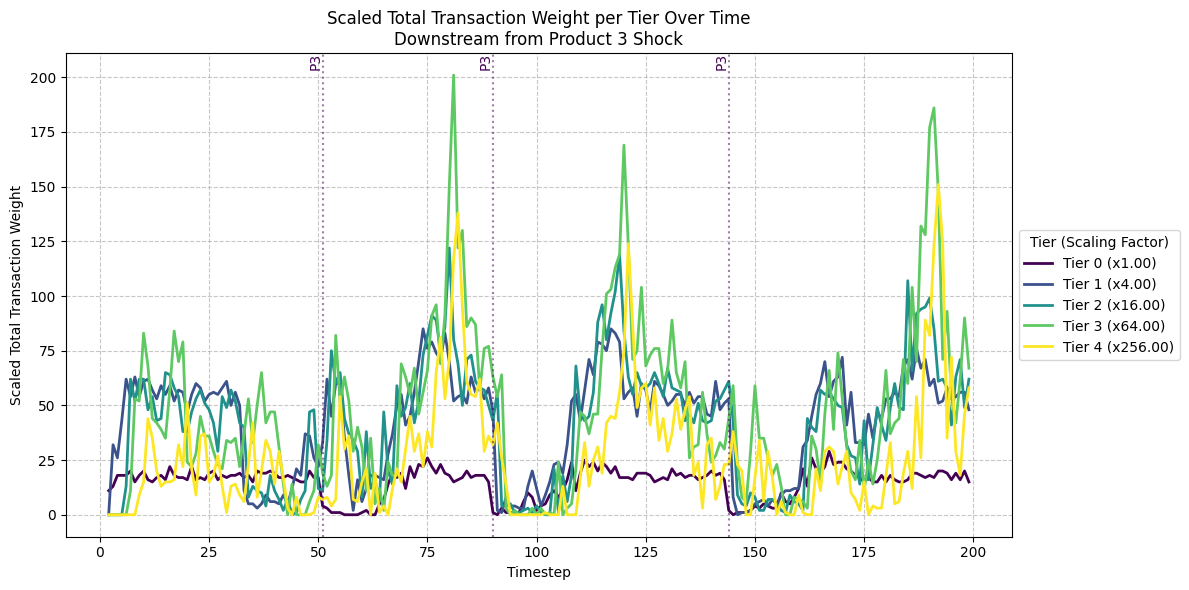

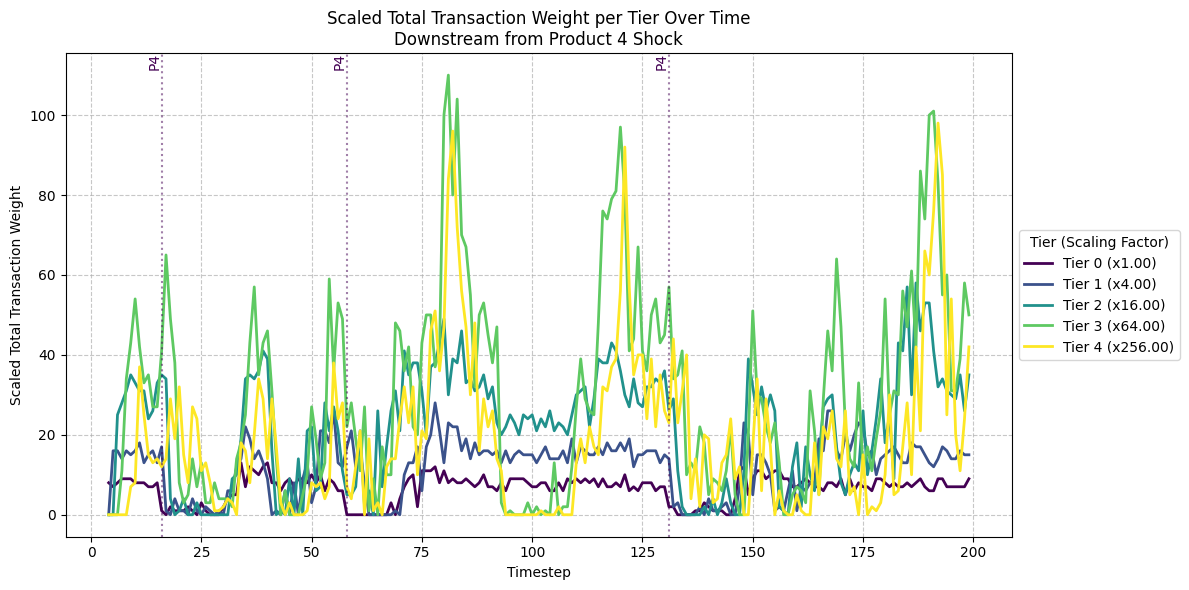

In [13]:
# Plot number of transactions per tier, per exogeneous supply and its downstream products 
# Scaled by product of max amount per between tiers to put amounts on the same scale
def calculate_scaling_factors(prod_graph, product_tiers):
    tier_ratios = {0: 1, 1: 1, 2: 1, 3: 1, 4: 1}
    
    for _, row in prod_graph.iterrows():
        source_tier = product_tiers[row['source']]
        dest_tier = product_tiers[row['dest']]
        if source_tier < dest_tier:
            ratio = row['units']
            tier_ratios[dest_tier] = max(tier_ratios[dest_tier], ratio)
    
    scaling_factors = {0: 1}
    for tier in range(1, 5):
        scaling_factors[tier] = scaling_factors[tier-1] * tier_ratios[tier]
    
    return scaling_factors

scaling_factors = calculate_scaling_factors(prod_graph, product_tiers)

print(f"scaling factors by tiers are: {scaling_factors}")

def get_product_tiers(prod_graph):
    tiers = {}
    products = set(prod_graph['source'].unique()) | set(prod_graph['dest'].unique())
    for product in products:
        i = int(product.replace('product', ''))
        if i < 5:
            tiers[product] = 0
        elif i < 15:
            tiers[product] = 1
        elif i < 25:
            tiers[product] = 2
        elif i < 35:
            tiers[product] = 3
        else:
            tiers[product] = 4
    return tiers

def get_downstream_products(prod_graph, start_product, max_tier):
    G = nx.DiGraph()
    for _, row in prod_graph.iterrows():
        G.add_edge(row['source'], row['dest'])
    
    downstream_products = set()
    current_tier = [start_product]
    for tier in range(max_tier + 1):
        next_tier = []
        for product in current_tier:
            downstream_products.add(product)
            next_tier.extend(list(G.successors(product)))
        current_tier = list(set(next_tier))
        if not current_tier:
            break
    return downstream_products

# Get product tiers
product_tiers = get_product_tiers(prod_graph)

# Create a mapping from product ID to tier
PROD_OFFSET = 119
product_id_to_tier = {int(prod_name.replace('product', '')) + PROD_OFFSET: tier 
                      for prod_name, tier in product_tiers.items()}

# Add tier information to the shock_data
shock_data['tier'] = shock_data['product'].map(product_id_to_tier)

for start_idx in [0, 2, 3, 4]:
    # Get downstream products for the first shock (product 0 at time 32)
    start_product = f'product{start_idx}'
    max_tier = 4  # Adjust this if you want to include more or fewer tiers
    downstream_products = get_downstream_products(prod_graph, start_product, max_tier)

    # Filter shock_data for downstream products and the relevant time period
    relevant_products = [int(p.replace('product', '')) + PROD_OFFSET for p in downstream_products]
    relevant_time_start = 0  # First shock time
    relevant_time_end = 199    # Adjust this to show more or less time after the shock
    filtered_shock_data = shock_data[
        (shock_data['product'].isin(relevant_products)) & 
        (shock_data['ts'] >= relevant_time_start) & 
        (shock_data['ts'] <= relevant_time_end)
    ]

    # Group by time and tier, sum the weights
    transactions_per_tier = filtered_shock_data.groupby(['ts', 'tier'])['weight'].sum().unstack(fill_value=0)

    # Apply scaling factors
    for tier in transactions_per_tier.columns:
        transactions_per_tier[tier] = transactions_per_tier[tier]

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))

    # Get the viridis colormap
    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, len(transactions_per_tier.columns)))

    # Plot each tier as a separate line
    for i, tier in enumerate(transactions_per_tier.columns):
        ax.plot(transactions_per_tier.index, transactions_per_tier[tier], 
                color=colors[i], label=f'Tier {tier} (x{scaling_factors[tier]:.2f})', linewidth=2)

    # Customize the plot
    ax.set_title(f'Scaled Total Transaction Weight per Tier Over Time\nDownstream from Product {start_idx} Shock')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Scaled Total Transaction Weight')
    ax.legend(title='Tier (Scaling Factor)', loc='center left', bbox_to_anchor=(1, 0.5))

    # Add grid for better readability
    ax.grid(True, linestyle='--', alpha=0.7)

    # Plot the shocks
    for product, times in shock_times.items():
        if product != start_idx + PROD_OFFSET: continue
        for time in times:
            ax.axvline(x=time, color=colors[0], linestyle=':', alpha=0.5)
            ax.text(time, ax.get_ylim()[1], f'P{product-PROD_OFFSET}', rotation=90, va='top', ha='right', color=colors[0])

    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()

In [ ]:
# TODO1: keep the same product graph, rerun the codes for generating ss-shock
# new argument: shock_probs_per_product
# change argument: shock_probs_per_time
# do the same plot like above, with stronger signals by only having 1 propagation for exogeneous product


# TODO2: metric
# metric: for each firm, product pair at time t, whether the # of txn < 50% of its historical average (last 10 timesteps)

# evaluate how good the metric is by
# -> if i mislabel a normal to shock: cross apply on SS-std, should get all negative labels
# -> if i missed a shock

# note: should not apply in first 10 timesteps (for warmup)
